In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# data splitting and cross validation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

# scaling
from sklearn.preprocessing import StandardScaler

# MLP model
from sklearn.neural_network import MLPClassifier

# metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X = covertype.data.features 
y = covertype.data.targets 
  
# metadata 
print(covertype.metadata) 
  
# variable information 
print(covertype.variables) 

{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [4]:
# if y is a one-column DataFrame, convert it to a series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# basic shape checks
print("X shape:", X.shape)
print("y shape:", y.shape)

# first few rows
print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 rows of y:")
display(y.head())

# check class distribution
print("\nClass distribution:")
print(y.value_counts().sort_index())

# check for missing values
print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

X shape: (581012, 54)
y shape: (581012,)

First 5 rows of X:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0



First 5 rows of y:


0    5
1    5
2    2
3    2
4    5
Name: Cover_Type, dtype: int64


Class distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Missing values in X:
0

Missing values in y:
0


In [5]:
# the first split is 80% for train validation and 20% test 
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# second split is from the 80% make 12.5% to validation giving 70% train and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

# check the sizes
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (406707, 54) (406707,)
Validation set shape: (58102, 54) (58102,)
Test set shape: (116203, 54) (116203,)


In [6]:
# MLP needs scaled features because neural networks are sensitive to feature magnitudes
scaler = StandardScaler()

# fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# use the same scaler on validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# also scale the combined train+val set for later CV if needed
X_train_val_scaled = scaler.fit_transform(X_train_val)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (406707, 54)
Scaled validation shape: (58102, 54)
Scaled test shape: (116203, 54)


In [7]:
# baseline MLP model
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=75,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5
)

# train the baseline model
baseline_mlp.fit(X_train_scaled, y_train)

# predictions
y_train_pred_base = baseline_mlp.predict(X_train_scaled)
y_val_pred_base = baseline_mlp.predict(X_val_scaled)

# accuracy
train_acc_base = accuracy_score(y_train, y_train_pred_base)
val_acc_base = accuracy_score(y_val, y_val_pred_base)

print("Baseline Training Accuracy:", train_acc_base)
print("Baseline Validation Accuracy:", val_acc_base)

Baseline Training Accuracy: 0.8361449397231914
Baseline Validation Accuracy: 0.8337922963064954


In [8]:
from sklearn.pipeline import Pipeline

# 5 fold stratified cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# build a pipeline so scaling happens correctly inside each fold
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=30,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    ))
])

# CV accuracy scores
cv_scores = cross_val_score(
    mlp_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

Cross-validation accuracy scores: [0.82102727 0.82381795 0.82175041 0.81835729 0.82450425]
Mean CV accuracy: 0.8218914327455493
Std CV accuracy: 0.0021815199802352695


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# smaller tuning grid to save time
param_grid = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (128, 64)],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate_init': [0.001]
}

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=30,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    ))
])

grid_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_mlp = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
Best Cross-Validation Accuracy: 0.890233011001094


C:\Users\12489\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
# predictions on training and validation sets
y_train_pred = best_mlp.predict(X_train)
y_val_pred = best_mlp.predict(X_val)

# accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print("Tuned Model Training Accuracy:", train_acc)
print("Tuned Model Validation Accuracy:", val_acc)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

Tuned Model Training Accuracy: 0.9003410317501297
Tuned Model Validation Accuracy: 0.8947196309937696
Validation Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.88      0.89     21184
           2       0.90      0.92      0.91     28330
           3       0.87      0.89      0.88      3576
           4       0.87      0.69      0.77       275
           5       0.78      0.67      0.72       949
           6       0.79      0.79      0.79      1737
           7       0.93      0.91      0.92      2051

    accuracy                           0.89     58102
   macro avg       0.86      0.82      0.84     58102
weighted avg       0.89      0.89      0.89     58102



In [16]:
# predict on test set
y_test_pred = best_mlp.predict(X_test)

# test accuracy
test_acc = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.8933246129617997


In [17]:
num_runs = 10
times = []

for _ in range(num_runs):
    start = time.time()
    best_mlp.predict(X_test)
    end = time.time()
    times.append(end - start)

print("Average inference time (seconds):", np.mean(times))
print("Std of inference time:", np.std(times))
print("Average time per sample:", np.mean(times) / len(X_test))

Average inference time (seconds): 0.33433687686920166
Std of inference time: 0.043918706291789726
Average time per sample: 2.8771793918332717e-06


Weighted Precision: 0.8929428733564099
Weighted Recall: 0.8933246129617997
Weighted F1-score: 0.8929488776445758

Test Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.88      0.89     42368
           2       0.90      0.92      0.91     56661
           3       0.87      0.90      0.88      7151
           4       0.86      0.68      0.76       549
           5       0.78      0.66      0.72      1899
           6       0.79      0.78      0.79      3473
           7       0.92      0.91      0.92      4102

    accuracy                           0.89    116203
   macro avg       0.86      0.82      0.84    116203
weighted avg       0.89      0.89      0.89    116203



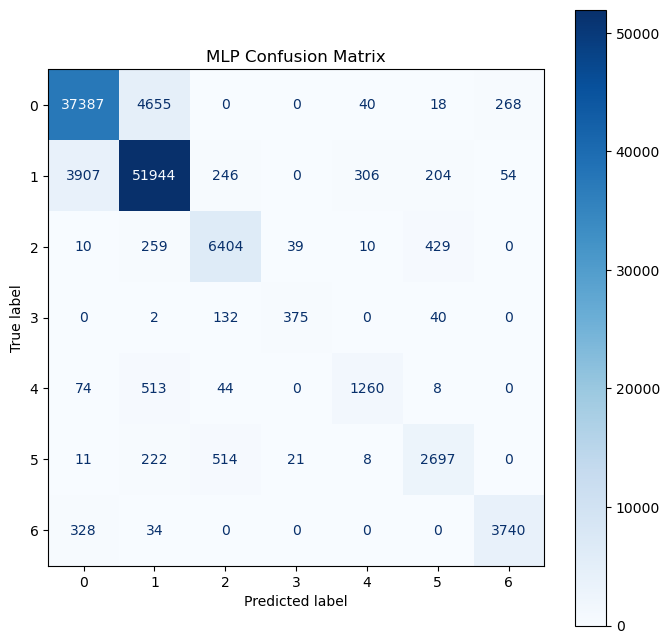

In [18]:
# precision, recall, f1 weighted
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average='weighted'
)

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

# full classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("MLP Confusion Matrix")
plt.show()

In [19]:
print("     FINAL RESULTS     ")
print("Best Parameters:", grid_search.best_params_)
print("Mean CV Accuracy:", grid_search.best_score_)
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

     FINAL RESULTS     
Best Parameters: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
Mean CV Accuracy: 0.890233011001094
Training Accuracy: 0.9003410317501297
Validation Accuracy: 0.8947196309937696
Test Accuracy: 0.8933246129617997
Weighted Precision: 0.8929428733564099
Weighted Recall: 0.8933246129617997
Weighted F1-score: 0.8929488776445758
